<a href="https://colab.research.google.com/github/JustusAkuku/Machine-Learning-Model-for-Salary-Prediction/blob/main/AI_ML_Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading the Dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content.drive')

df = pd.read_csv("/content.drive/MyDrive/salary_dataset.csv")
df


Mounted at /content.drive


,EmployeeID,Age,YearsExperience,YearsAtCompany,Department,EducationLevel,PerformanceRating,MonthlyHoursWorked,MonthlySalary
0,1,44,26,13.0,Sales,Bachelor,4.0,160.0,167000.0
1,2,38,18,0.0,Engineering,Bachelor,4.0,163.0,174000.0
2,3,46,24,3.0,Sales,Master,5.0,159.0,223000.0
3,4,55,31,12.0,Engineering,High School,1.0,148.0,125000.0
4,5,37,17,11.0,HR,Bachelor,2.0,172.0,115000.0
...,...,...,...,...,...,...,...,...,...
995,996,37,18,9.0,Sales,Bachelor,4.0,161.0,159000.0
996,997,57,34,14.0,Operations,Bachelor,4.0,161.0,157000.0
997,998,46,21,2.0,Engineering,Master,2.0,160.0,194000.0
998,999,34,11,4.0,Engineering,High School,2.0,156.0,112000.0


# Dataset Quality

In [ ]:
# How many rows and columns?
print("Shape:", df.shape)

#Column names
print("\nColumns:", df.columns.to_list())

# Data types
print("\nData Types:\n", df.dtypes)

# First 5 rows
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 9)

Columns: ['EmployeeID', 'Age', 'YearsExperience', 'YearsAtCompany', 'Department', 'EducationLevel', 'PerformanceRating', 'MonthlyHoursWorked', 'MonthlySalary']

Data Types:
 EmployeeID              int64
Age                     int64
YearsExperience         int64
YearsAtCompany        float64
Department             object
EducationLevel         object
PerformanceRating     float64
MonthlyHoursWorked    float64
MonthlySalary         float64
dtype: object

First 5 rows:


,EmployeeID,Age,YearsExperience,YearsAtCompany,Department,EducationLevel,PerformanceRating,MonthlyHoursWorked,MonthlySalary
0,1,44,26,13.0,Sales,Bachelor,4.0,160.0,167000.0
1,2,38,18,0.0,Engineering,Bachelor,4.0,163.0,174000.0
2,3,46,24,3.0,Sales,Master,5.0,159.0,223000.0
3,4,55,31,12.0,Engineering,High School,1.0,148.0,125000.0
4,5,37,17,11.0,HR,Bachelor,2.0,172.0,115000.0


In [ ]:
# Missing Values
print("\nMissing Values:",df.isnull().sum())

#Duplicates
print("\nDuplicates:",df.duplicated().sum())


Missing Values: EmployeeID             0
Age                    0
YearsExperience        0
YearsAtCompany        54
Department             0
EducationLevel         0
PerformanceRating     51
MonthlyHoursWorked    52
MonthlySalary          0
dtype: int64

Duplicates: 0


In [ ]:
#Remove missing values
df_clean = df.dropna()
df_clean

,EmployeeID,Age,YearsExperience,YearsAtCompany,Department,EducationLevel,PerformanceRating,MonthlyHoursWorked,MonthlySalary
0,1,44,26,13.0,Sales,Bachelor,4.0,160.0,167000.0
1,2,38,18,0.0,Engineering,Bachelor,4.0,163.0,174000.0
2,3,46,24,3.0,Sales,Master,5.0,159.0,223000.0
3,4,55,31,12.0,Engineering,High School,1.0,148.0,125000.0
4,5,37,17,11.0,HR,Bachelor,2.0,172.0,115000.0
...,...,...,...,...,...,...,...,...,...
995,996,37,18,9.0,Sales,Bachelor,4.0,161.0,159000.0
996,997,57,34,14.0,Operations,Bachelor,4.0,161.0,157000.0
997,998,46,21,2.0,Engineering,Master,2.0,160.0,194000.0
998,999,34,11,4.0,Engineering,High School,2.0,156.0,112000.0


In [ ]:
#Confirm eliminating missing values
print("\nMissing Values:",df_clean.isnull().sum())


Missing Values: EmployeeID            0
Age                   0
YearsExperience       0
YearsAtCompany        0
Department            0
EducationLevel        0
PerformanceRating     0
MonthlyHoursWorked    0
MonthlySalary         0
dtype: int64


#Exploratory Data Analysis

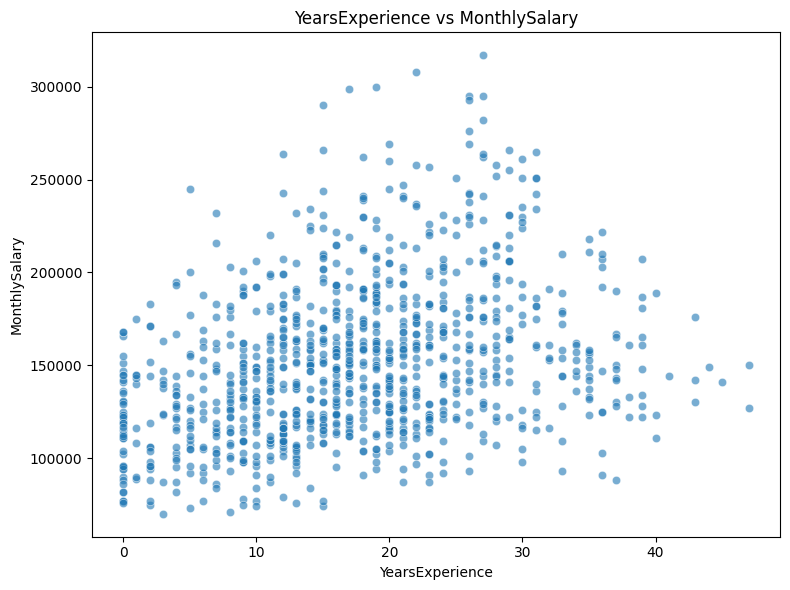

In [ ]:
# 1. YearsExperience Vs MonthlySalary
plt.figure(figsize=(8, 6))
sns.scatterplot(x='YearsExperience', y='MonthlySalary', data=df, alpha=0.6)


plt.title('YearsExperience vs MonthlySalary')
plt.xlabel('YearsExperience')
plt.ylabel('MonthlySalary')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

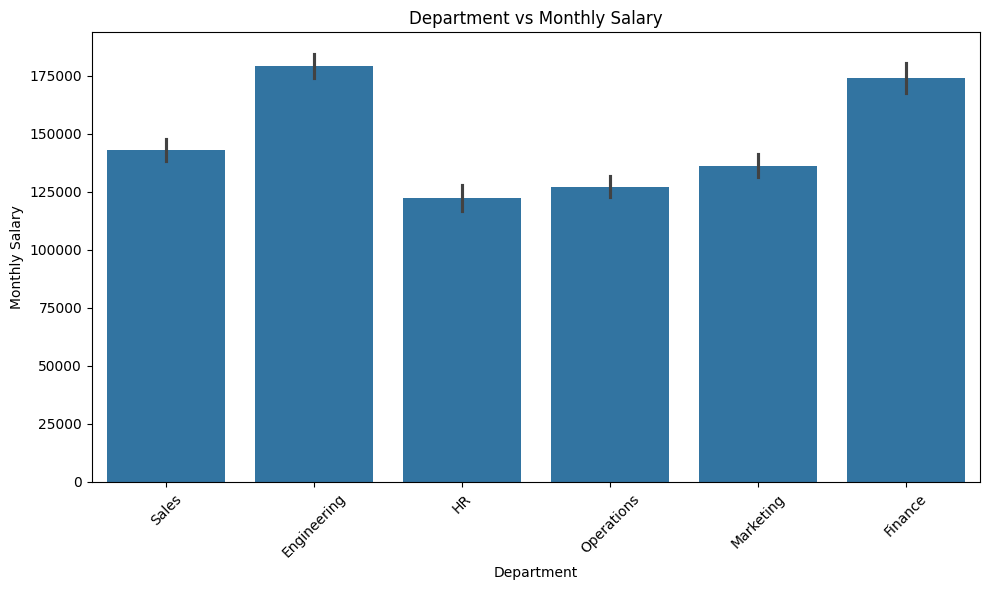

In [ ]:
#2. Department Vs Monthly Salary
plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='MonthlySalary', data=df)
plt.title('Department vs Monthly Salary')
plt.xlabel('Department')
plt.ylabel('Monthly Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


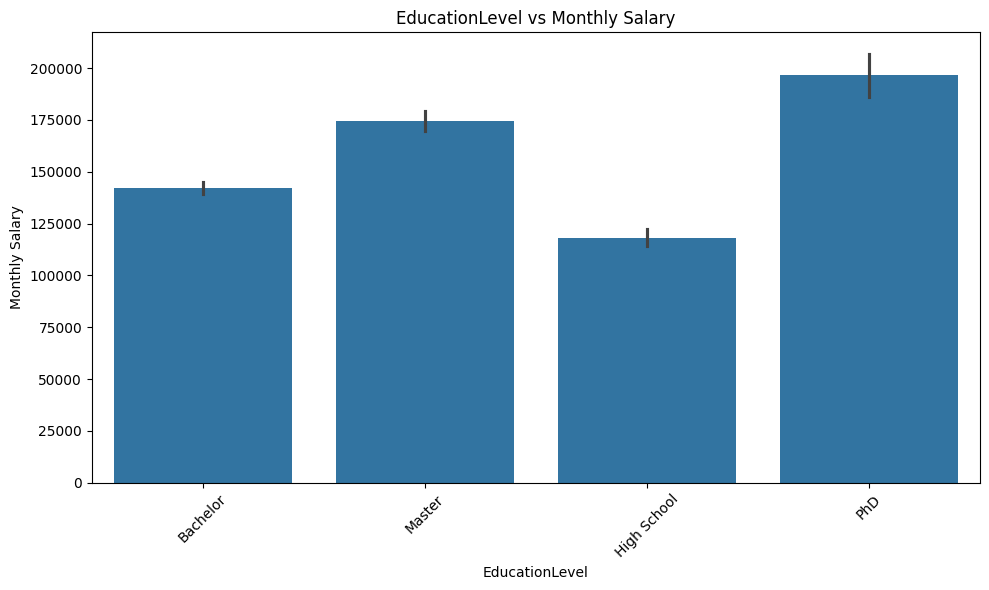

In [ ]:
#EducationLevel Vs MonthlySalary
plt.figure(figsize=(10, 6))
sns.barplot(x='EducationLevel', y='MonthlySalary', data=df)
plt.title('EducationLevel vs Monthly Salary')
plt.xlabel('EducationLevel')
plt.ylabel('Monthly Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

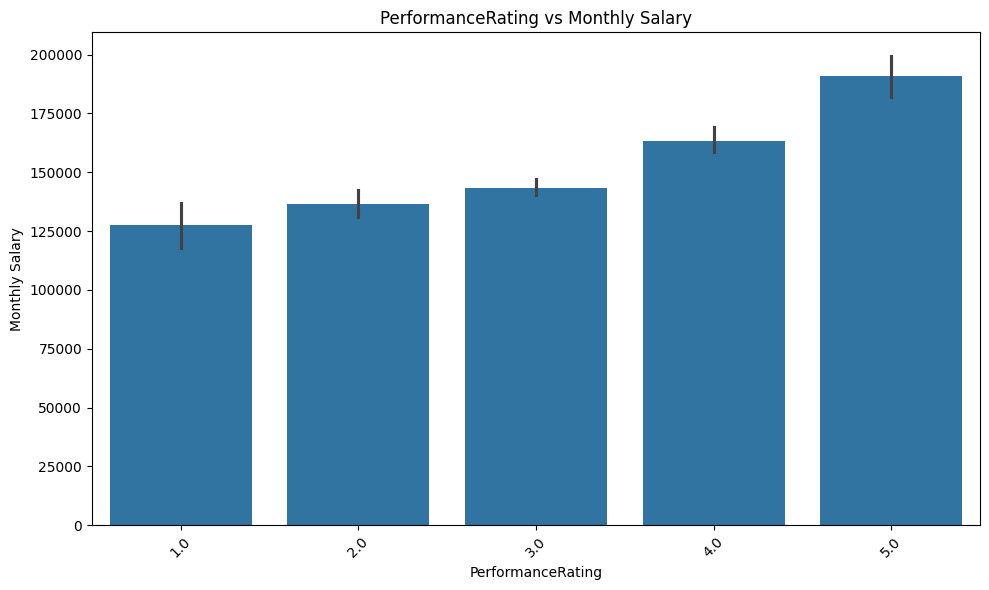

In [ ]:
#PerformanceRating Vs MonthlySalary
plt.figure(figsize=(10, 6))
sns.barplot(x='PerformanceRating', y='MonthlySalary', data=df)
plt.title('PerformanceRating vs Monthly Salary')
plt.xlabel('PerformanceRating')
plt.ylabel('Monthly Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Feature Engineering

In [ ]:
#Encoding Categorical variables

In [ ]:
#encoding dummies
dummies = pd.get_dummies(df_clean.Department, df_clean.EducationLevel)
dummies = dummies.astype(int)
dummies

,"0 Bachelor\n1 Bachelor\n2 Master\n3 High School\n4 Bachelor\n ... \n995 Bachelor\n996 Bachelor\n997 Master\n998 High School\n999 Master\nName: EducationLevel, Length: 853, dtype: object_Engineering","0 Bachelor\n1 Bachelor\n2 Master\n3 High School\n4 Bachelor\n ... \n995 Bachelor\n996 Bachelor\n997 Master\n998 High School\n999 Master\nName: EducationLevel, Length: 853, dtype: object_Finance","0 Bachelor\n1 Bachelor\n2 Master\n3 High School\n4 Bachelor\n ... \n995 Bachelor\n996 Bachelor\n997 Master\n998 High School\n999 Master\nName: EducationLevel, Length: 853, dtype: object_HR","0 Bachelor\n1 Bachelor\n2 Master\n3 High School\n4 Bachelor\n ... \n995 Bachelor\n996 Bachelor\n997 Master\n998 High School\n999 Master\nName: EducationLevel, Length: 853, dtype: object_Marketing","0 Bachelor\n1 Bachelor\n2 Master\n3 High School\n4 Bachelor\n ... \n995 Bachelor\n996 Bachelor\n997 Master\n998 High School\n999 Master\nName: EducationLevel, Length: 853, dtype: object_Operations","0 Bachelor\n1 Bachelor\n2 Master\n3 High School\n4 Bachelor\n ... \n995 Bachelor\n996 Bachelor\n997 Master\n998 High School\n999 Master\nName: EducationLevel, Length: 853, dtype: object_Sales"
0,0,0,0,0,0,1
1,1,0,0,0,0,0
2,0,0,0,0,0,1
3,1,0,0,0,0,0
4,0,0,1,0,0,0
...,...,...,...,...,...,...
995,0,0,0,0,0,1
996,0,0,0,0,1,0
997,1,0,0,0,0,0
998,1,0,0,0,0,0


In [ ]:
department_dummies = pd.get_dummies(df_clean['Department'], prefix='Department').astype(int)
education_dummies = pd.get_dummies(df_clean['EducationLevel'], prefix='Education').astype(int)

df_encoded = pd.concat([df_clean, department_dummies, education_dummies], axis=1)
df_encoded = df_encoded.drop(columns=['Department', 'EducationLevel'])

display(df_encoded.head())

,EmployeeID,Age,YearsExperience,YearsAtCompany,PerformanceRating,MonthlyHoursWorked,MonthlySalary,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,Education_Bachelor,Education_High School,Education_Master,Education_PhD
0,1,44,26,13.0,4.0,160.0,167000.0,0,0,0,0,0,1,1,0,0,0
1,2,38,18,0.0,4.0,163.0,174000.0,1,0,0,0,0,0,1,0,0,0
2,3,46,24,3.0,5.0,159.0,223000.0,0,0,0,0,0,1,0,0,1,0
3,4,55,31,12.0,1.0,148.0,125000.0,1,0,0,0,0,0,0,1,0,0
4,5,37,17,11.0,2.0,172.0,115000.0,0,0,1,0,0,0,1,0,0,0


In [ ]:
#Dropping Columns not needed for feature engineering
columns_to_drop = ['EmployeeID', 'MonthlyHoursWorked', 'Age']
df_encoded = df_encoded.drop(columns=columns_to_drop)
display(df_encoded.head())

,YearsExperience,YearsAtCompany,PerformanceRating,MonthlySalary,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,Education_Bachelor,Education_High School,Education_Master,Education_PhD
0,26,13.0,4.0,167000.0,0,0,0,0,0,1,1,0,0,0
1,18,0.0,4.0,174000.0,1,0,0,0,0,0,1,0,0,0
2,24,3.0,5.0,223000.0,0,0,0,0,0,1,0,0,1,0
3,31,12.0,1.0,125000.0,1,0,0,0,0,0,0,1,0,0
4,17,11.0,2.0,115000.0,0,0,1,0,0,0,1,0,0,0


In [ ]:
#Drop one column per categorical variable
df_encoded = df_encoded.drop(columns=['Department_Sales', 'Education_High School'])
display(df_encoded.head())

,YearsExperience,YearsAtCompany,PerformanceRating,MonthlySalary,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Education_Bachelor,Education_Master,Education_PhD
0,26,13.0,4.0,167000.0,0,0,0,0,0,1,0,0
1,18,0.0,4.0,174000.0,1,0,0,0,0,1,0,0
2,24,3.0,5.0,223000.0,0,0,0,0,0,0,1,0
3,31,12.0,1.0,125000.0,1,0,0,0,0,0,0,0
4,17,11.0,2.0,115000.0,0,0,1,0,0,1,0,0


In [ ]:
df_encoded

,YearsExperience,YearsAtCompany,PerformanceRating,MonthlySalary,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Education_Bachelor,Education_Master,Education_PhD
0,26,13.0,4.0,167000.0,0,0,0,0,0,1,0,0
1,18,0.0,4.0,174000.0,1,0,0,0,0,1,0,0
2,24,3.0,5.0,223000.0,0,0,0,0,0,0,1,0
3,31,12.0,1.0,125000.0,1,0,0,0,0,0,0,0
4,17,11.0,2.0,115000.0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,18,9.0,4.0,159000.0,0,0,0,0,0,1,0,0
996,34,14.0,4.0,157000.0,0,0,0,0,1,1,0,0
997,21,2.0,2.0,194000.0,1,0,0,0,0,0,1,0
998,11,4.0,2.0,112000.0,1,0,0,0,0,0,0,0


In [ ]:
#Splitting Data into Train and Test sets
from sklearn.model_selection import train_test_split
X = df_encoded.drop('MonthlySalary', axis = 'columns')
y = df_encoded.MonthlySalary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)
len(X_train), len(X_test)

(682, 171)

In [ ]:
#Model Deployment
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8753009304779854

In [25]:
# Predict salaries on the test set
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[101742.67695671 234641.25727758 153328.79068322 183262.63148845
  87406.2875599  155585.9754207  196294.76121336 152538.45271399
 129585.70644448 206188.03457139]


In [ ]:
#Comparison between the predicted and actual values
comparison = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': predictions
})

comparison.head(10)

,Actual Salary,Predicted Salary
0,98000.0,101742.676957
1,258000.0,234641.257278
2,144000.0,153328.790683
3,195000.0,183262.631488
4,94000.0,87406.287560
5,148000.0,155585.975421
6,192000.0,196294.761213
7,149000.0,152538.452714
8,117000.0,129585.706444
9,206000.0,206188.034571


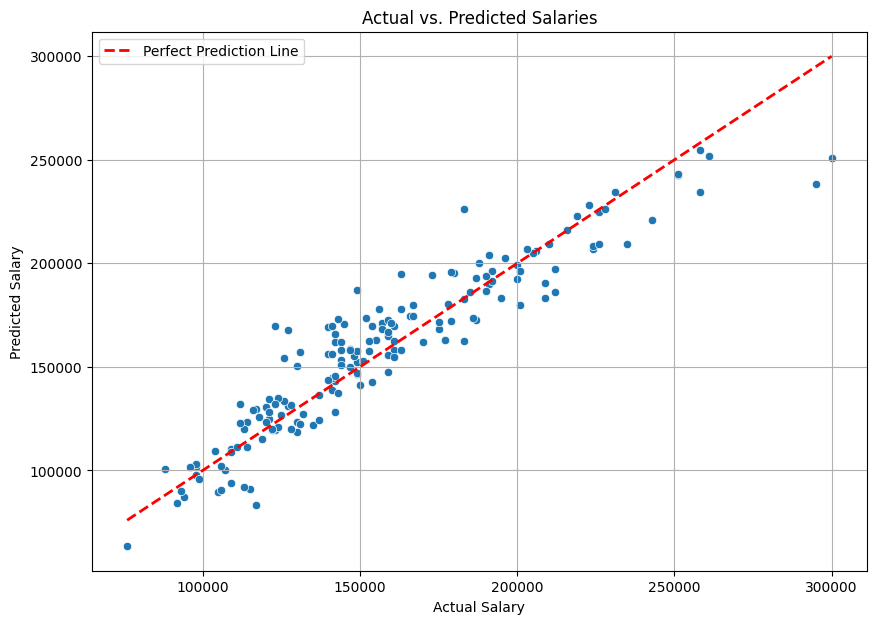

In [ ]:
#Scatter plot to show comparison between predicted and actual salaries
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Salary', y='Predicted Salary', data=comparison)
plt.title('Actual vs. Predicted Salaries')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.plot([comparison['Actual Salary'].min(), comparison['Actual Salary'].max()],
         [comparison['Actual Salary'].min(), comparison['Actual Salary'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Predicting Salary for a new employee
new_employee_data = {
    'YearsExperience': [5],
    'YearsAtCompany': [3],
    'PerformanceRating': [4],
    'Department': ['Engineering'],
    'EducationLevel': ['Bachelor']
}

# Create a DataFrame for the new employee
new_employee_df = pd.DataFrame(new_employee_data)

# Apply one-hot encoding and reindex to match X_train columns
# This automatically handles the dropped reference columns and ensures correct order
new_employee_processed = pd.get_dummies(new_employee_df, columns=['Department', 'EducationLevel'], prefix=['Department', 'Education'], dtype=int)

# Drop the reference columns that were dropped in X_train
new_employee_processed = new_employee_processed.drop(columns=['Department_Sales', 'Education_High School'], errors='ignore')

# Reindex to ensure all columns from X_train are present, filling missing with 0
# This handles cases where a department/education level might not be in the new employee but was in training
new_employee_processed = new_employee_processed.reindex(columns=X_train.columns, fill_value=0)

predicted_salary = model.predict(new_employee_processed)

print(predicted_salary)

[168745.88683103]


#Model Evaluation

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation
-----------------------------
Mean Absolute Error (MAE): 11104.756932775957
Mean Squared Error (MSE): 227007122.77573657
Root Mean Squared Error (RMSE): 15066.755549080119
R² Score: 0.8753009304779854
